In [1]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
%matplotlib inline
plt.style.use('default')

In [2]:
# importing file and making it read latin

file_path = r"C:\Users\Quantum\Downloads\DataCoSupplyChainDataset.csv"
df = pd.read_csv(file_path, encoding='latin1')
df_work = df.copy()

In [3]:
# data exploration

print("=== 1. spreadsheet dimensions (Rows, Columns) ===")
print(df.shape)

print("\n=== 2. data in each column ===")
df.info()

print("\n=== 3. count of blank cells ===")
missing_counts = df.isna().sum()
print(missing_counts[missing_counts > 0])

print("\n=== 4. count of duplicated rows ===")
print(df.duplicated().sum())

print("\n=== 5. statistical summary of numeric columns ===")
print(df.describe())

print("\n=== 6. sneak peek of the first 5 rows ===")
print(df.head())

=== 1. spreadsheet dimensions (Rows, Columns) ===
(180519, 53)

=== 2. data in each column ===
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Custome

In [4]:
# Expanded to drop completely useless columns with high missing rates or zero data right away
columns_to_drop = [
    'Categ ory Id', 'Customer Id', 'Customer Zipcode', 'Order Id', 
    'Order Item Cardprod Id', 'Product Card Id', 'Benefit per order', 
    'Order Item Total', 'Order Item Product Price', 'Department Id', 
    'Product Category Id', 'Order Customer Id', 'Order Item Id', 
    'Customer Fname', 'Customer Lname', 'Customer Street', 
    'Latitude', 'Longitude', 'Order Item Discount Rate',
    'Product Description', 'Order Zipcode'
]
df_work = df_work.drop(columns=columns_to_drop, errors='ignore')

In [5]:
# Clean up impossible dates where shipping happens before the order date
df_work = df_work[df_work['shipping date (DateOrders)'] >= df_work['order date (DateOrders)']]

In [6]:
# Overwrite missing discount entries with 0.0 to stabilize mathematical calculations
if 'Order Item Discount' in df_work.columns:
    df_work['Order Item Discount'] = df_work['Order Item Discount'].fillna(0.0)

In [7]:
# filling empty cells

if 'Order Item Discount' in df_work.columns:
    df_work['Order Item Discount'] = df_work['Order Item Discount'].fillna(0)

In [8]:
#  whitespace cleanup to ensure categories match perfectly without spaces
for col in ['Category Name', 'Type', 'Order Status', 'Order Region', 'Customer Segment', 'Shipping Mode']:
    if col in df_work.columns:
        df_work[col] = df_work[col].astype(str).str.strip()

In [9]:
# change date format



df_work['order date (DateOrders)'] = pd.to_datetime(df_work['order date (DateOrders)'])
df_work['shipping date (DateOrders)'] = pd.to_datetime(df_work['shipping date (DateOrders)'])

In [10]:
# filling empty cells

if 'Order Item Discount' in df_work.columns:
    df_work['Order Item Discount'] = df_work['Order Item Discount'].fillna(0)

In [11]:
# handling outliers winsorizing
q1_sales = df_work['Sales'].quantile(0.25)
q3_sales = df_work['Sales'].quantile(0.75)
iqr_sales = q3_sales - q1_sales
lower_bound_sales = q1_sales - 1.5 * iqr_sales
upper_bound_sales = q3_sales + 1.5 * iqr_sales

In [12]:
# removing identical rows

df_work = df_work.drop_duplicates()

In [13]:
# changing time stamps into months and calculating total profit through multiplying quantity and profit per order

df_work['Order_YearMonth'] = df_work['order date (DateOrders)'].dt.to_period('M').astype(str)
df_work['Total_Item_Profit'] = df_work['Order Item Quantity'] * df_work['Order Profit Per Order']

# ordedr completion track checks if order = complete returns true or false changed into 1 and 0 for mapping

df_work['Is_Complete'] = (df_work['Order Status'] == 'COMPLETE').astype(int)

# Create binary fraud check mapping directly onto the work array
df_work['Is_Fraud'] = (df_work['Order Status'] == 'SUSPECTED_FRAUD').astype(int)

In [14]:
# calculating target vs actual transit durations as a risk flag
shipping_bias_profile = df_work.groupby('Shipping Mode').agg({
    'Days for shipment (scheduled)': 'mean',
    'Days for shipping (real)': 'mean',
    'Late_delivery_risk': 'mean'
})

In [15]:
df_work['Is_Returned'] = (df_work['Total_Item_Profit'] < 0).astype(int)

In [16]:
# Filter out product returns and cancellations (negative profit lines) so they do not count as negatives in gross analysis
df_commercial = df_work[df_work['Total_Item_Profit'] >= 0].copy()

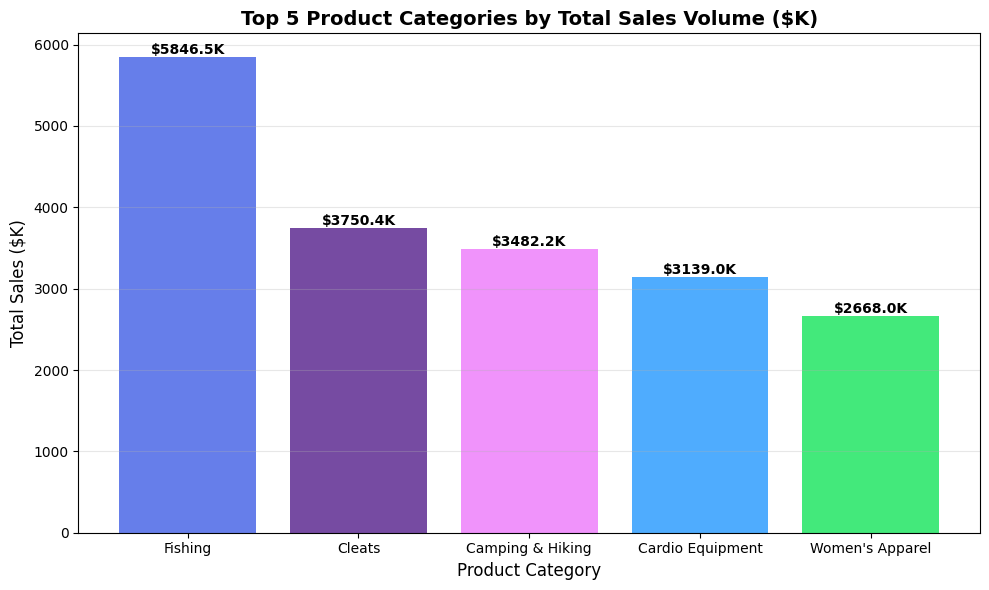

In [17]:
# chart - 1 top revenue categories

# summing up sales by category selecting top 5 then changing to list and dividing by thousand to fit in chart (don't remove the /1000)

top_categories = df_work.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(5)
categories = top_categories.index.tolist()
sales_thousands = (top_categories.values / 1000).round(1)

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, sales_thousands, color=['#667eea', '#764ba2', '#f093fb', '#4facfe', '#43e97b'])
plt.title('Top 5 Product Categories by Total Sales Volume ($K)', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($K)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i in range(len(categories)):
    plt.text(categories[i], sales_thousands[i], f'${sales_thousands[i]}K', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

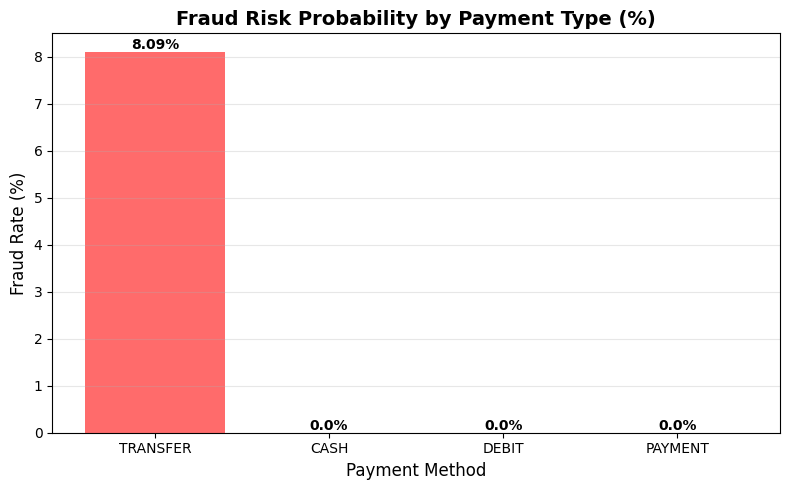

In [18]:
# chart - 2 fraud risk by payment method

# tracking fraud status with a binary indicator returning true or false changed into 1 or 0 for tracking

df_work['Is_Fraud'] = (df_work['Order Status'] == 'SUSPECTED_FRAUD').astype(int)
fraud_by_type = df_work.groupby('Type')['Is_Fraud'].mean() * 100
fraud_by_type = fraud_by_type.sort_values(ascending=False)
pay_methods = fraud_by_type.index.tolist()
fraud_rates = fraud_by_type.values.round(2)

plt.figure(figsize=(8, 5))
type_bars = plt.bar(pay_methods, fraud_rates, color='#ff6b6b')
plt.title('Fraud Risk Probability by Payment Type (%)', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Fraud Rate (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i in range(len(pay_methods)):
    plt.text(pay_methods[i], fraud_rates[i], f'{fraud_rates[i]}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

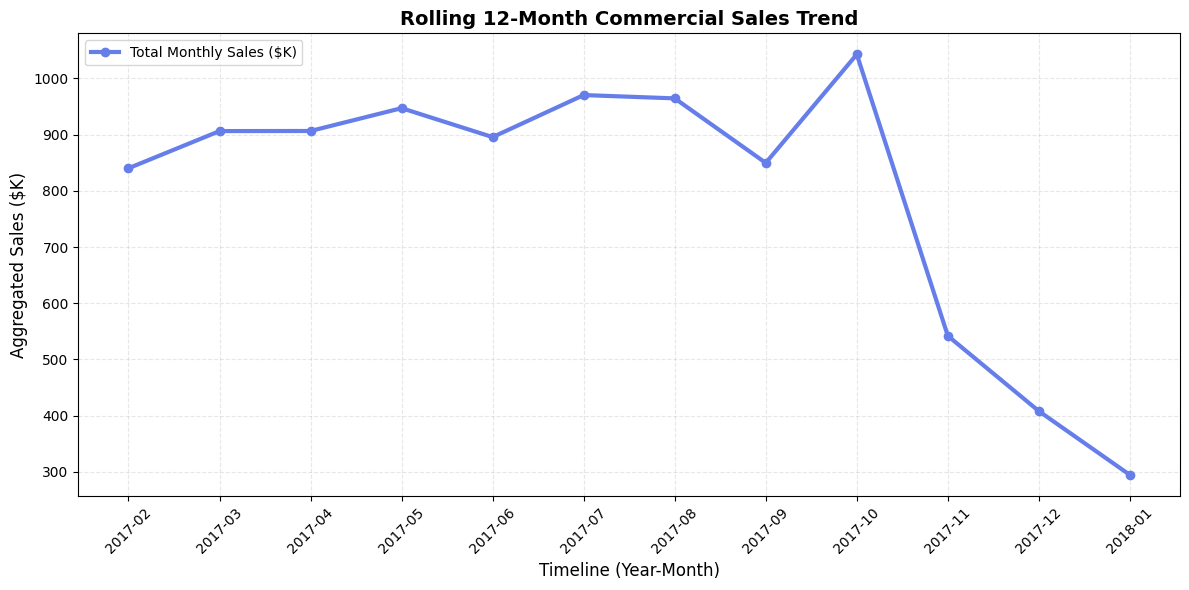

In [19]:
# chart - 3 monthly sales

# grouping sales by month summing up and extracting only the last 12 months (reset index to be able to run operations on months again)

monthly_sales = df_work.groupby('Order_YearMonth')['Sales'].sum().reset_index()
monthly_sample = monthly_sales.sort_values('Order_YearMonth').tail(12)

timeline = monthly_sample['Order_YearMonth'].values
trend_values = (monthly_sample['Sales'].values / 1000).round(1)

plt.figure(figsize=(12, 6))
plt.plot(timeline, trend_values, marker='o', linewidth=3, label='Total Monthly Sales ($K)', color='#667eea')
plt.title('Rolling 12-Month Commercial Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Aggregated Sales ($K)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

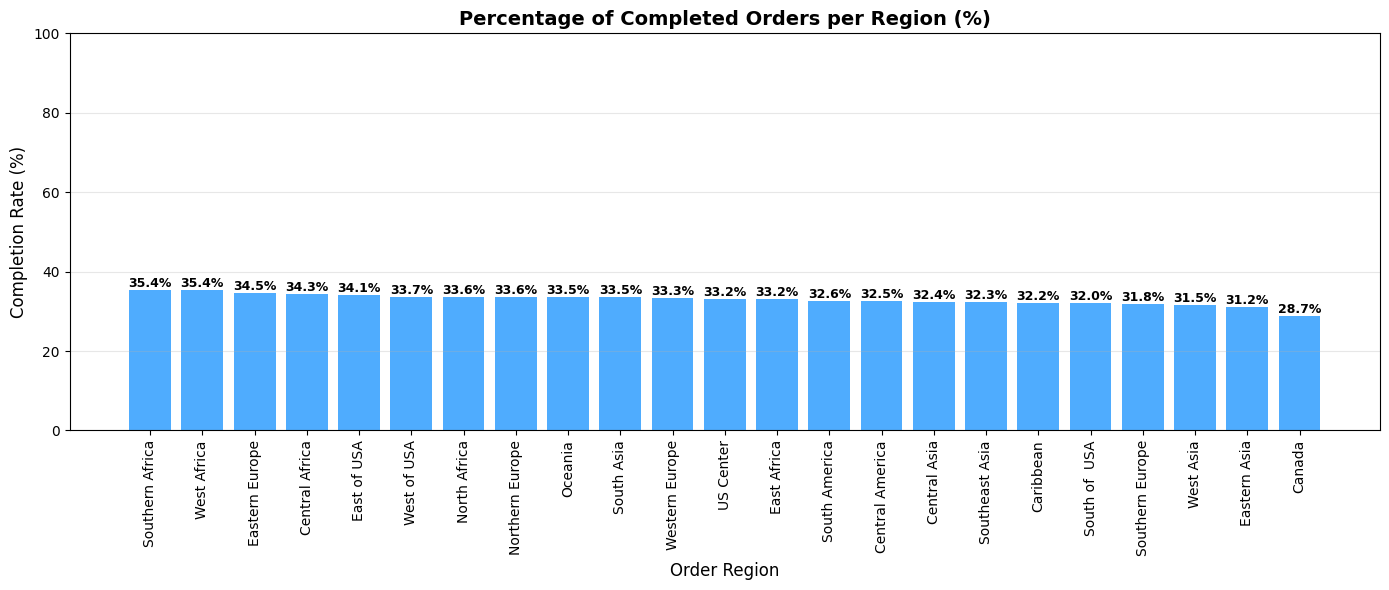

In [20]:
# chart - 4 order completion rate by region

# using the mean of the Is_complete to calculate the percentage of completed orders per region

region_completion = df_work.groupby('Order Region')['Is_Complete'].mean().sort_values(ascending=False) * 100
regions = region_completion.index.tolist()
completion_rates = region_completion.values.round(1)

plt.figure(figsize=(14, 6))
completion_bars = plt.bar(regions, completion_rates, color='#4facfe')
plt.title('Percentage of Completed Orders per Region (%)', fontsize=14, fontweight='bold')
plt.xlabel('Order Region', fontsize=12)
plt.ylabel('Completion Rate (%)', fontsize=12)
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

for i in range(len(regions)):
    plt.text(regions[i], completion_rates[i], f'{completion_rates[i]}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

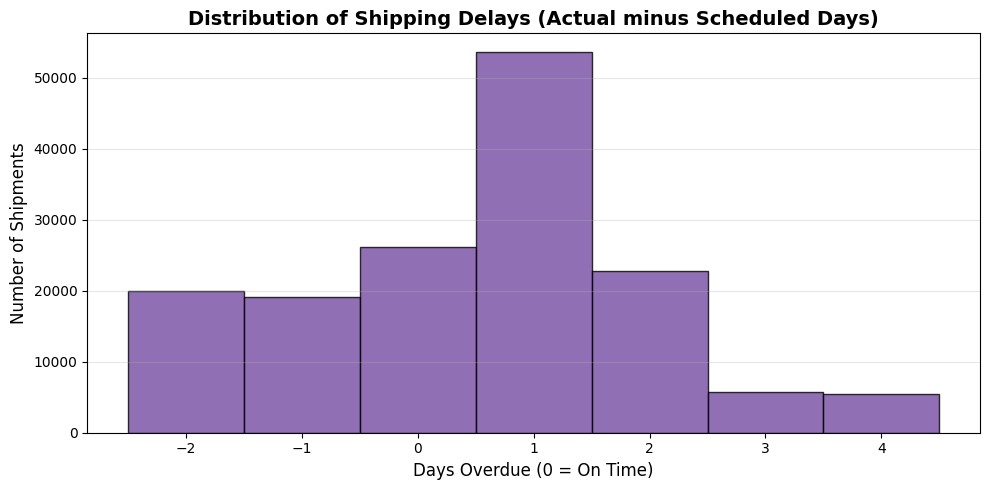

In [21]:
# chart - 5 shipping delays per class

df_work['Shipping_Delay_Days'] = df_work['Days for shipping (real)'] - df_work['Days for shipment (scheduled)']

plt.figure(figsize=(10, 5))
plt.hist(df_work['Shipping_Delay_Days'], bins=np.arange(df_work['Shipping_Delay_Days'].min()-0.5, df_work['Shipping_Delay_Days'].max()+1.5, 1), color='#764ba2', edgecolor='black', alpha=0.8)
plt.title('Distribution of Shipping Delays (Actual minus Scheduled Days)', fontsize=14, fontweight='bold')
plt.xlabel('Days Overdue (0 = On Time)', fontsize=12)
plt.ylabel('Number of Shipments', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

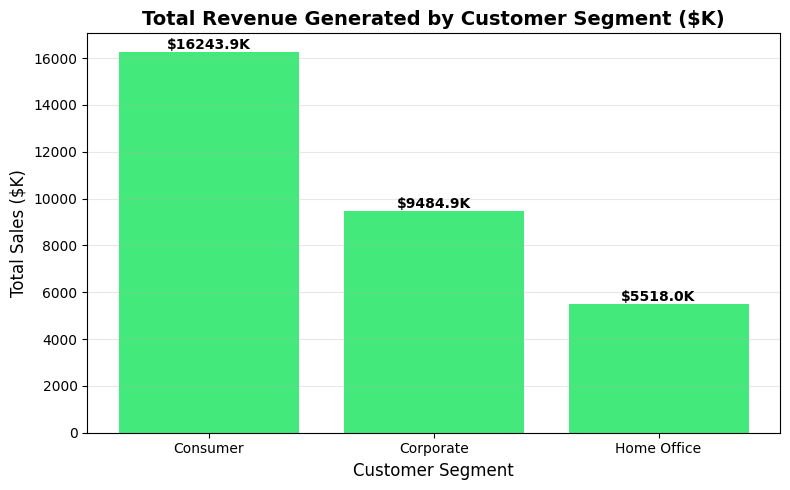

In [22]:
# chart - 6 revenue per customer type/segment

segment_sales = df_work.groupby('Customer Segment')['Sales'].sum().sort_values(ascending=False)
segment_names = segment_sales.index.tolist()
segment_sales_thousands = (segment_sales.values / 1000).round(1)

plt.figure(figsize=(8, 5))
segment_bars = plt.bar(segment_names, segment_sales_thousands, color='#43e97b')
plt.title('Total Revenue Generated by Customer Segment ($K)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Sales ($K)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for i in range(len(segment_names)):
    plt.text(segment_names[i], segment_sales_thousands[i], f'${segment_sales_thousands[i]}K', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

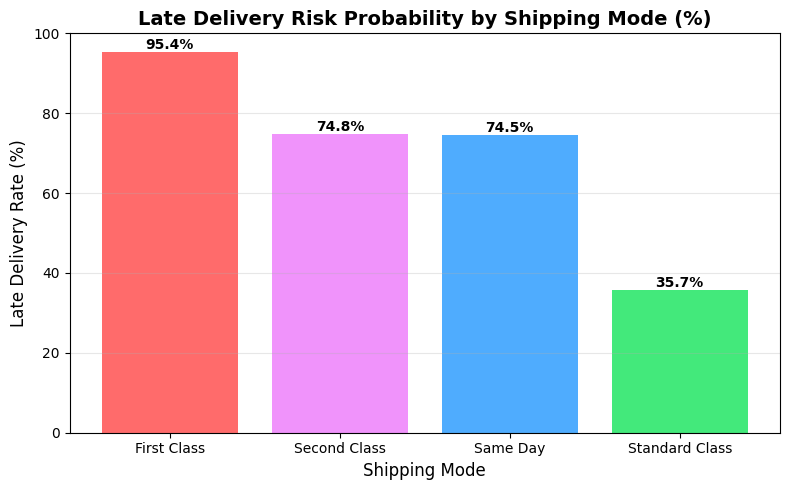

In [23]:
# chart - 7 lateness risk per shipping mode


shipping_lateness = df_work.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100
shipping_lateness = shipping_lateness.sort_values(ascending=False)
modes = shipping_lateness.index.tolist()
late_rates = shipping_lateness.values.round(1)

plt.figure(figsize=(8, 5))
plt.bar(modes, late_rates, color=['#ff6b6b', '#f093fb', '#4facfe', '#43e97b'])
plt.title('Late Delivery Risk Probability by Shipping Mode (%)', fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Late Delivery Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

for i in range(len(modes)):
    plt.text(modes[i], late_rates[i], f'{late_rates[i]}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()